# 🚀 Poverty Prediction: Advanced Modeling & Optimization
**Goal:** Leveraging Feature Engineering and Ensemble Learning to reach maximum predictive accuracy.

---
## 🛠️ Step 1: Feature Engineering & Domain Logic
In this section, we transform raw household data into powerful "Socio-Economic Ratios" like:
* **Children Ratio:** (Children / Family Size)
* **Room Density:** (Rooms / Person)
* **Education-Crowding Index:** (Mean Education * Overcrowding)

In [35]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Load the cleaned dataset
df_clean = pd.read_csv('Data/train_cleaned.csv')
print(f"Original shape: {df_clean.shape}")

# ==========================================
# Step 1: Feature Aggregation (Individual to Household)
# ==========================================
ind_cols = ['age', 'escolari', 'rez_esc']

print("Aggregating individual features...")
aggs = df_clean.groupby('idhogar')[ind_cols].agg(['min', 'max', 'mean', 'sum', 'std'])

# Flatten the multi-level columns
aggs.columns = [f"{col[0]}_{col[1]}" for col in aggs.columns]

# Fill NaN std for single-person households
for col in ind_cols:
    aggs[f'{col}_std'] = aggs[f'{col}_std'].fillna(0)

aggs = aggs.reset_index()

# ==========================================
# Step 2: Merge & Create Advanced Ratios
# ==========================================
# Filter for head of household
df_household = df_clean[df_clean['parentesco1'] == 1].copy()

# Rename head's individual columns
df_household.rename(columns={
    'age': 'head_age', 
    'escolari': 'head_escolari', 
    'rez_esc': 'head_rez_esc'
}, inplace=True)

# Merge
df_final = pd.merge(df_household, aggs, on='idhogar', how='left')

# ✨ NEW: Adding Advanced Ratios for better Accuracy ✨
# These features were identified in the model_improvement phase
print("Adding advanced household ratios...")

# 1. Children ratio: Percentage of young children in the house
if 'r4t1' in df_final.columns and 'tamhog' in df_final.columns:
    df_final['children_ratio'] = df_final['r4t1'] / (df_final['tamhog'] + 1e-5)

# 2. Rooms per person: Measures overcrowding density
if 'rooms' in df_final.columns and 'tamhog' in df_final.columns:
    df_final['rooms_per_person'] = df_final['rooms'] / (df_final['tamhog'] + 1e-5)

# 3. Education x Overcrowding: Interaction between socio-economic factors
if 'meaneduc' in df_final.columns and 'overcrowding' in df_final.columns:
    df_final['educ_overcrowding'] = df_final['meaneduc'] * df_final['overcrowding']

# 4. Dependency x Education: Impact of dependency on household education
if 'dependency' in df_final.columns and 'meaneduc' in df_final.columns:
    df_final['dependency_educ'] = df_final['dependency'] * df_final['meaneduc']

# ==========================================
# Step 3: Cleanup and Save
# ==========================================
cols_to_drop = ['Id', 'idhogar', 'parentesco1'] 
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

print(f"Final dataset shape (with Advanced Features): {df_final.shape}")

# Save the updated engineered dataset
df_final.to_csv('Data/train_engineered.csv', index=False)
print("Updated engineered dataset successfully saved!")

Original shape: (9557, 142)
Aggregating individual features...
Adding advanced household ratios...
Final dataset shape (with Advanced Features): (2973, 159)
Updated engineered dataset successfully saved!


### 🔎 : Feature Importance & Validation
Before moving to the final modeling phase, we must validate our newly engineered features. 
We will train a baseline **Random Forest Classifier** to extract the **Feature Importance**. This tells us which variables (original or engineered) carry the most weight in predicting household poverty. 
*Note: Random Forests do not require scaling, making this the perfect time to evaluate the raw engineered dataset.*

Analyzing the importance of all features... ⏳


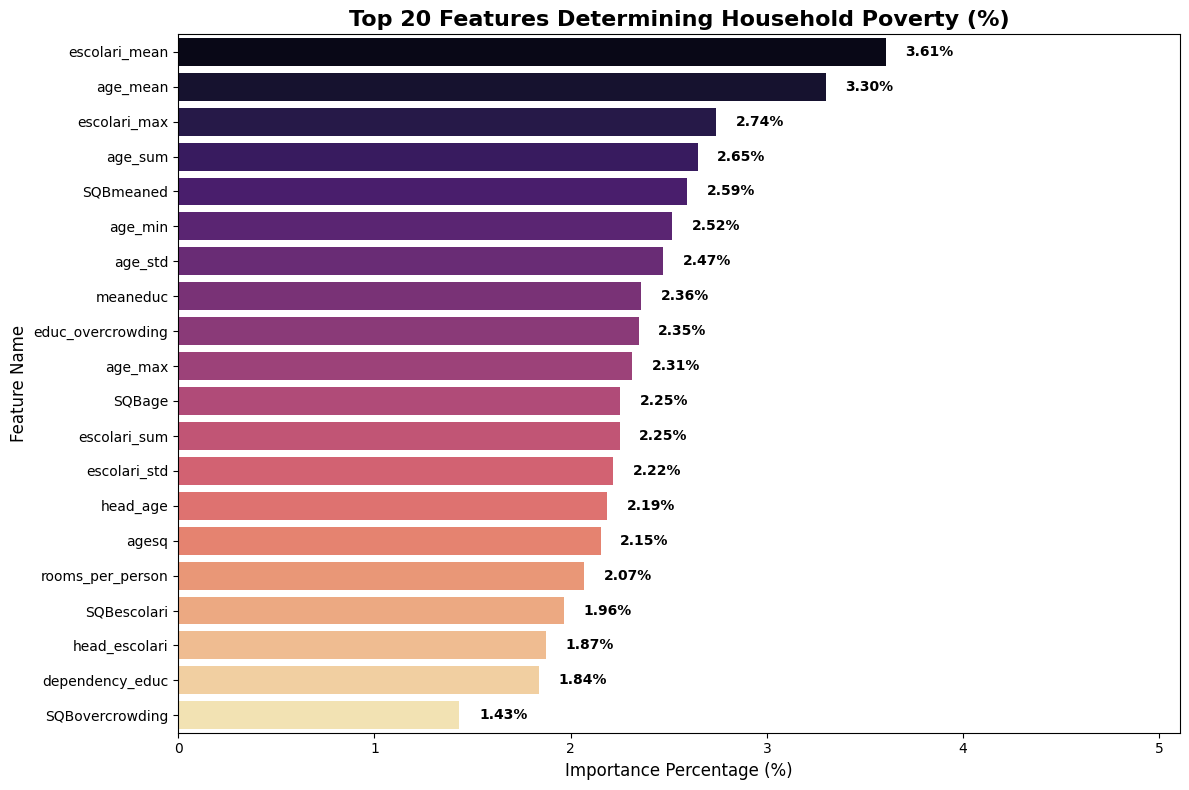


--- Top 10 Features by Percentage ---
          Feature Importance (%)
    escolari_mean          3.61%
         age_mean          3.30%
     escolari_max          2.74%
          age_sum          2.65%
        SQBmeaned          2.59%
          age_min          2.52%
          age_std          2.47%
         meaneduc          2.36%
educ_overcrowding          2.35%
          age_max          2.31%


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Load the engineered dataset
df = pd.read_csv('Data/train_engineered.csv')

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['Target'])
y = df['Target']

# 3. Train a baseline model strictly to extract feature importance
print("Analyzing the importance of all features... ⏳")
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X, y)

# 4. Extract, convert to percentage, and sort features by their importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': rf.feature_importances_ * 100  # Convert to percentage
}).sort_values(by='Importance (%)', ascending=False)

top_20 = feature_importances.head(20)

# 5. Plot the Top 20 Features with Data Labels
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Importance (%)', y='Feature', data=top_20, palette='magma')

# Add percentage labels at the end of each bar
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.1, 
            p.get_y() + p.get_height() / 2, 
            f'{width:.2f}%', 
            ha='left', va='center', fontsize=10, fontweight='bold')

plt.title('Top 20 Features Determining Household Poverty (%)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Percentage (%)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
# Add some extra limit to x-axis so the text labels don't get cut off
plt.xlim(0, top_20['Importance (%)'].max() + 1.5) 
plt.tight_layout()
plt.show()

# 6. Print the top 10 features as a clean table
print("\n--- Top 10 Features by Percentage ---")
top_10_print = feature_importances.head(10).copy()
top_10_print['Importance (%)'] = top_10_print['Importance (%)'].apply(lambda x: f"{x:.2f}%")
print(top_10_print.to_string(index=False))

### ⚙️ Phase 3: Data Refinement (Outlier Handling & Scaling)

After completing the feature engineering, we must prepare the numerical data for the machine learning model. This phase ensures that extreme values and different scales do not negatively impact the model's performance.

#### **Step 1: Handling Outliers (Capping / Winsorization)**
We address **Outliers** (extreme values) that can mislead the model. Instead of deleting rows, we use **Capping**:
* **Mechanism:** We set a threshold at the **1st percentile** and the **99th percentile**. Any value beyond these limits is "clipped" to the threshold.
* **Benefit:** This stabilizes the data variance without losing valuable household information.

#### **Step 2: Feature Scaling (MinMaxScaler)**
Machine learning algorithms perform better when all features are on the same scale. We use **MinMaxScaler**:
* **Range:** Every value is compressed into a range between **0 and 1**.
* **Why now?** Since we already capped the outliers, the scaling is now highly effective and safe.



#### **Step 3: Final Dataset Reconstruction**
The target variable is re-attached to the newly scaled features, resulting in a **Pristine Dataset** (`train_scaled.csv`) that is 100% ready for the training phase.

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Load the engineered dataset
df = pd.read_csv('Data/train_engineered.csv')
print(f"Original shape before Outlier Handling & Scaling: {df.shape}")

# Separate Target from Features
X = df.drop(columns=['Target'])
y = df['Target']

# Get numerical columns only 
num_cols = X.select_dtypes(include=[np.number]).columns

# ==========================================
# Step 1: Handling Outliers (Capping / Winsorization)
# ==========================================
print("Capping extreme outliers...")
for col in num_cols:
    # We skip binary columns (0 and 1) from outlier treatment
    if X[col].nunique() > 2:
        lower_limit = X[col].quantile(0.01)
        upper_limit = X[col].quantile(0.99)
        
        # Clip values to be within the 1% and 99% limits
        X[col] = X[col].clip(lower=lower_limit, upper=upper_limit)

# ==========================================
# Step 2: Feature Scaling (MinMaxScaler)
# ==========================================
print("Applying MinMax Scaling...")
scaler = MinMaxScaler()

# Fit and transform the numerical features
X_scaled = pd.DataFrame(scaler.fit_transform(X[num_cols]), columns=num_cols)

# ==========================================
# Step 3: Reconstruct the DataFrame and Save
# ==========================================
# Add the Target column back to the scaled features
df_final = X_scaled.copy()
df_final['Target'] = y.values

# Save the final pristine dataset
df_final.to_csv('Data/train_scaled.csv', index=False)
print("Outliers handled and features scaled successfully!")
print("Final pristine dataset saved as: 'Data/train_scaled.csv'")

Original shape before Outlier Handling & Scaling: (2973, 155)
Capping extreme outliers...


C:\Users\ag\AppData\Local\Temp\ipykernel_11176\3589206171.py:27: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].clip(lower=lower_limit, upper=upper_limit)
C:\Users\ag\AppData\Local\Temp\ipykernel_11176\3589206171.py:27: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col]

Applying MinMax Scaling...
Outliers handled and features scaled successfully!
Final pristine dataset saved as: 'Data/train_scaled.csv'


### ⚖️ Step 3.5: Advanced Data Balancing (SMOTETomek)

Now that our data is scaled, we apply **SMOTETomek**. This is a hybrid technique that:
1. **Oversamples** the minority poverty classes using SMOTE.
2. **Cleans** the dataset by removing "Tomek Links" (noisy, overlapping samples between classes).
This ensures the model has clear boundaries to distinguish between different poverty levels.

In [38]:
from imblearn.combine import SMOTETomek
import pandas as pd

# 1. Load the scaled data directly
df_scaled = pd.read_csv('Data/train_scaled.csv')

# 2. Separate Features and Target
# We use the full multi-class 'Target' (1, 2, 3, 4) to preserve all information
X = df_scaled.drop(columns=['Target'])
y = df_scaled['Target']

# 3. Apply SMOTETomek
print("Applying SMOTETomek to balance and clean the dataset... ⏳")
smt = SMOTETomek(random_state=42)
X_resampled, y_resampled = smt.fit_resample(X, y)

# 4. Show results
print("\n✅ Data Balancing Complete!")
print(f"Original samples: {len(y)}")
print(f"Resampled samples: {len(y_resampled)}")
print("\nNew Class Distribution:")
print(pd.Series(y_resampled).value_counts().sort_index())

# Save these for the next cell (Modeling)
# From now on, use X_resampled and y_resampled for training!

Applying SMOTETomek to balance and clean the dataset... ⏳

✅ Data Balancing Complete!
Original samples: 2973
Resampled samples: 7814

New Class Distribution:
Target
1    1954
2    1953
3    1954
4    1953
Name: count, dtype: int64


# 🤖 Phase 4: Machine Learning Modeling & Evaluation

### 🎯 Objective
With the dataset engineered, capped, and scaled, we now move to the final predictive modeling phase. Our goal is to build a robust classifier capable of identifying vulnerable households.

### ⚙️ Strategic Steps
1. **Target Transformation (Binary Classification):** To improve model focus and provide actionable insights, we transform the problem from multi-class to binary. Classes 1, 2, and 3 are grouped as **Poverty (1)**, while Class 4 remains **Non-Poverty (0)**.
2. **Train-Test Split:** We split the data (80% training, 20% testing) using `stratify=y` to ensure the original class distribution is preserved in both sets.
3. **Handling Class Imbalance (SMOTE):** We apply **Synthetic Minority Over-sampling Technique (SMOTE)** *strictly* to the training data. This prevents the model from being biased toward the majority class (Non-Poverty) without leaking synthetic data into our realistic test set.
4. **Model Training & Evaluation:** We deploy a **Random Forest Classifier**, an ensemble method highly effective at capturing non-linear relationships. Results are formatted in percentages for clear business reporting.

Training the Binary Model... ⏳

🎯 --- Final Model Performance Metrics --- 🎯
Overall Accuracy: 72.77%
Macro F1-Score:   70.19%

Detailed Classification Report (%) :
             precision  recall f1-score support
Non-Poverty     80.21%  77.75%   78.96%  391.0%
Poverty         59.72%  63.24%   61.43%  204.0%
accuracy        72.77%  72.77%   72.77%   0.73%
macro avg       69.97%  70.49%   70.19%  595.0%
weighted avg    73.19%  72.77%   72.95%  595.0%


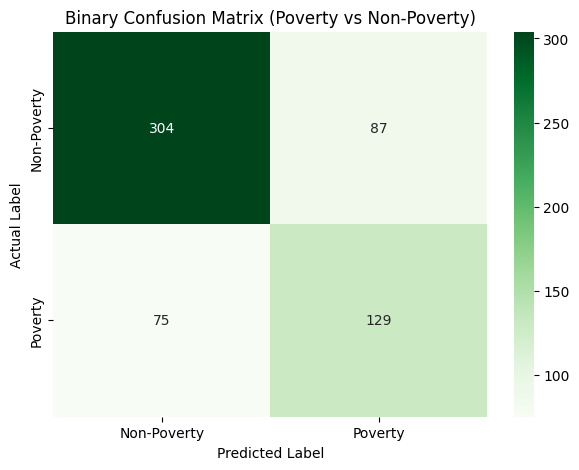

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

# 1. Load the dataset
df = pd.read_csv('Data/train_scaled.csv')

# 2. Convert to Binary Classification
# Classes 1, 2, 3 -> Poverty (1) | Class 4 -> Non-Poverty (0)
df['Target_Binary'] = df['Target'].replace({1: 1, 2: 1, 3: 1, 4: 0})

# 3. Separate Features and Target
X = df.drop(columns=['Target', 'Target_Binary'])
y = df['Target_Binary']

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 6. Train the Binary Model
print("Training the Binary Model... ⏳")
binary_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
binary_model.fit(X_train_smote, y_train_smote)

# 7. Predictions
y_pred = binary_model.predict(X_test)

# ==========================================
# Step 8: Calculate Metrics in Percentages (%)
# ==========================================
acc = accuracy_score(y_test, y_pred) * 100
f1_macro = f1_score(y_test, y_pred, average='macro') * 100

print("\n🎯 --- Final Model Performance Metrics --- 🎯")
print(f"Overall Accuracy: {acc:.2f}%")
print(f"Macro F1-Score:   {f1_macro:.2f}%")

print("\nDetailed Classification Report (%) :")
# Generate the report as a dictionary to format it manually into percentages
report = classification_report(y_test, y_pred, target_names=['Non-Poverty', 'Poverty'], output_dict=True)

# Formatting the report to show % 
report_df = pd.DataFrame(report).transpose()
report_df.iloc[:, :-1] = report_df.iloc[:, :-1] * 100  # Multiply metrics by 100 (except support)
print(report_df.round(2).astype(str) + '%')

# 9. Plot the Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Poverty', 'Poverty'],
            yticklabels=['Non-Poverty', 'Poverty'])
plt.title('Binary Confusion Matrix (Poverty vs Non-Poverty)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Searching for the best Model Parameters... This might take a minute ⏳")

# 1. Define the parameter grid (The settings we want to test)
param_grid = {
    'n_estimators': [100, 200, 300, 500],          # Number of trees
    'max_depth': [None, 10, 20, 30, 40],           # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],               # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],                 # Minimum samples required at each leaf node
    'class_weight': ['balanced', 'balanced_subsample', None] 
}

# 2. Setup the RandomizedSearchCV
rf_base = RandomForestClassifier(random_state=42)
rf_tuned = RandomizedSearchCV(estimator=rf_base, 
                              param_distributions=param_grid, 
                              n_iter=20,               # Try 20 different random combinations
                              cv=3,                    # 3-fold Cross Validation
                              scoring='f1_macro',      # Optimize specifically for Macro F1-Score
                              n_jobs=-1,               # Use all processor cores
                              random_state=42,
                              verbose=1)

# 3. Fit the tuned model on the SMOTE training data
# (Assuming X_train_smote and y_train_smote are already defined from your previous code)
rf_tuned.fit(X_train_smote, y_train_smote)

# Print the best settings found
print("\n🏆 Best Parameters Found:")
print(rf_tuned.best_params_)

# 4. Predict and Evaluate with the BEST model
best_model = rf_tuned.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# Calculate new metrics
acc_tuned = accuracy_score(y_test, y_pred_tuned) * 100
f1_macro_tuned = f1_score(y_test, y_pred_tuned, average='macro') * 100

print("\n🎯 --- Tuned Model Performance Metrics --- 🎯")
print(f"Overall Accuracy: {acc_tuned:.2f}%")
print(f"Macro F1-Score:   {f1_macro_tuned:.2f}%")

print("\nDetailed Classification Report (%) :")
report_tuned = classification_report(y_test, y_pred_tuned, target_names=['Non-Poverty', 'Poverty'], output_dict=True)
report_df_tuned = pd.DataFrame(report_tuned).transpose()
report_df_tuned.iloc[:, :-1] = report_df_tuned.iloc[:, :-1] * 100  
print(report_df_tuned.round(2).astype(str) + '%')

Searching for the best Model Parameters... This might take a minute ⏳
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🏆 Best Parameters Found:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30, 'class_weight': None}

🎯 --- Tuned Model Performance Metrics --- 🎯
Overall Accuracy: 73.11%
Macro F1-Score:   70.63%

Detailed Classification Report (%) :
             precision  recall f1-score support
Non-Poverty     80.64%  77.75%   79.17%  391.0%
Poverty         60.09%  64.22%   62.09%  204.0%
accuracy        73.11%  73.11%   73.11%   0.73%
macro avg       70.36%  70.98%   70.63%  595.0%
weighted avg    73.59%  73.11%   73.31%  595.0%


### 🚀 Step 6: Advanced Modeling with XGBoost
To push our predictive performance to the maximum, we implement **XGBoost (Extreme Gradient Boosting)**. 
Unlike Random Forest (which builds independent trees), XGBoost builds trees sequentially, where each new tree strictly focuses on correcting the errors made by the previous ones. This often yields superior accuracy and F1-scores on tabular datasets.

Training the XGBoost Model... 🚀


c:\Users\ag\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:47:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🚀 --- XGBoost Model Performance Metrics --- 🚀
Overall Accuracy: 76.81%
Macro F1-Score:   74.20%

Detailed Classification Report (%) :
             precision  recall f1-score support
Non-Poverty     82.19%  82.61%    82.4%  391.0%
Poverty         66.34%  65.69%   66.01%  204.0%
accuracy        76.81%  76.81%   76.81%   0.77%
macro avg       74.26%  74.15%    74.2%  595.0%
weighted avg    76.75%  76.81%   76.78%  595.0%


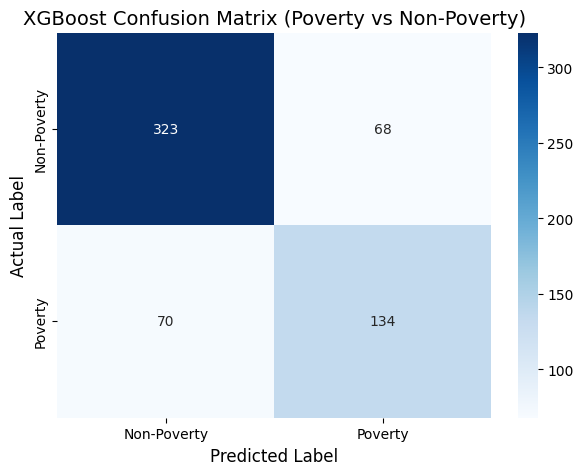

In [26]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Training the XGBoost Model... 🚀")

# 1. Initialize XGBoost Classifier
# We use standard powerful hyperparameters for a strong baseline
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss' # Ensures no warnings appear during training
)

# 2. Fit the model on the SMOTE balanced data
xgb_model.fit(X_train_smote, y_train_smote)

# 3. Predict on the unseen test set
y_pred_xgb = xgb_model.predict(X_test)

# 4. Calculate Metrics in Percentages (%)
acc_xgb = accuracy_score(y_test, y_pred_xgb) * 100
f1_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro') * 100

print("\n🚀 --- XGBoost Model Performance Metrics --- 🚀")
print(f"Overall Accuracy: {acc_xgb:.2f}%")
print(f"Macro F1-Score:   {f1_macro_xgb:.2f}%")

print("\nDetailed Classification Report (%) :")
report_xgb = classification_report(y_test, y_pred_xgb, target_names=['Non-Poverty', 'Poverty'], output_dict=True)
report_df_xgb = pd.DataFrame(report_xgb).transpose()
report_df_xgb.iloc[:, :-1] = report_df_xgb.iloc[:, :-1] * 100  
print(report_df_xgb.round(2).astype(str) + '%')

# 5. Plot the Confusion Matrix (Using 'Blues' to distinguish from Random Forest)
plt.figure(figsize=(7, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Poverty', 'Poverty'],
            yticklabels=['Non-Poverty', 'Poverty'])
plt.title('XGBoost Confusion Matrix (Poverty vs Non-Poverty)', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

### 🧪 Phase 5: Experimental Approach (Decision Boundary Shift & Under-Sampling)

**Hypothesis:** Our previous models might have struggled to separate the classes because **Class 3 (Vulnerable)** shares many physical and economic characteristics with **Class 4 (Non-Vulnerable)**. Additionally, generating synthetic data via SMOTE might have introduced unnecessary noise.

**The Strategy:**
To test this hypothesis, we will implement a two-step experimental strategy:

1. **Decision Boundary Shift (Target Re-Grouping):**
   We will shift the boundary of our binary classification.
   * **Poverty (1):** Classes 1 (Extreme) and 2 (Moderate).
   * **Stable (0):** Classes 3 (Vulnerable) and 4 (Non-Vulnerable).
   * *Objective:* Create a sharper, more distinct contrast between true poverty and relative stability.

2. **Random Under-Sampling (Replacing SMOTE):**
   Instead of generating synthetic data to artificially inflate the minority class, we will randomly drop rows from the majority class (Stable) until both classes are perfectly balanced.
   * *Objective:* Train the model exclusively on **100% real, observed data** to prevent the algorithm from learning synthetic noise.

Let's test this custom strategy using the XGBoost classifier to see if refining our logical assumptions yields higher predictive accuracy!

Experimenting with Jimmy's Strategy (New Grouping + UnderSampling)... 🔬

Cutting down the majority class to exactly match the minority class... ✂️
Original Training Shape: 2378 rows
New Training Shape after UnderSampling: 1062 rows

Training XGBoost... 🚀
Overall Accuracy: 70.59%
Macro F1-Score:   65.93%

Detailed Classification Report (%) :
                    precision  recall f1-score support
Stable/Well-off (0)    90.65%  69.26%   78.53%  462.0%
Poverty (1)            41.32%  75.19%   53.33%  133.0%
accuracy               70.59%  70.59%   70.59%   0.71%
macro avg              65.99%  72.23%   65.93%  595.0%
weighted avg           79.63%  70.59%    72.9%  595.0%


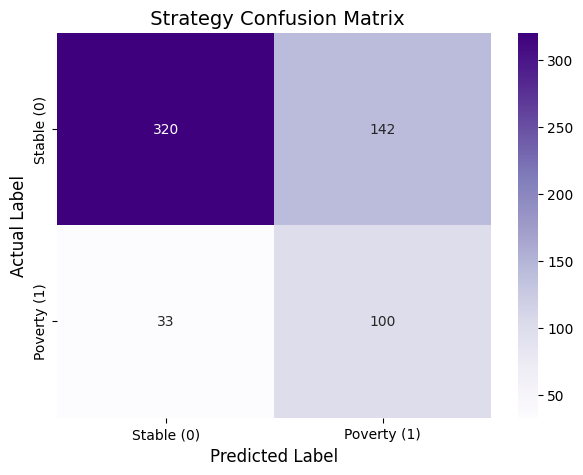

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore') # To hide any red warnings

print("Experimenting with Jimmy's Strategy (New Grouping + UnderSampling)... 🔬")

# ==========================================
# Step 1: Jimmy's New Grouping Strategy
# ==========================================
df = pd.read_csv('Data/train_scaled.csv')

# Classes 1 (Extreme) & 2 (Moderate) -> Poverty (1)
# Classes 3 (Vulnerable) & 4 (Non-Vulnerable) -> Non-Poverty / Stable (0)
df['Target_Binary'] = df['Target'].replace({1: 1, 2: 1, 3: 0, 4: 0})

X = df.drop(columns=['Target', 'Target_Binary'])
y = df['Target_Binary']

# ==========================================
# Step 2: Split BEFORE UnderSampling
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# Step 3: Jimmy's UnderSampling Strategy
# ==========================================
print("\nCutting down the majority class to exactly match the minority class... ✂️")
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Original Training Shape: {X_train.shape[0]} rows")
print(f"New Training Shape after UnderSampling: {X_train_rus.shape[0]} rows")

# ==========================================
# Step 4: Train XGBoost on the new setup
# ==========================================
print("\nTraining XGBoost... 🚀")
xgb_rus = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, 
    eval_metric='logloss'
)
xgb_rus.fit(X_train_rus, y_train_rus)

# ==========================================
# Step 5: Evaluate
# ==========================================
y_pred_rus = xgb_rus.predict(X_test)

acc_rus = accuracy_score(y_test, y_pred_rus) * 100
f1_macro_rus = f1_score(y_test, y_pred_rus, average='macro') * 100

print(f"Overall Accuracy: {acc_rus:.2f}%")
print(f"Macro F1-Score:   {f1_macro_rus:.2f}%")

print("\nDetailed Classification Report (%) :")
report_rus = classification_report(y_test, y_pred_rus, target_names=['Stable/Well-off (0)', 'Poverty (1)'], output_dict=True)
report_df_rus = pd.DataFrame(report_rus).transpose()
report_df_rus.iloc[:, :-1] = report_df_rus.iloc[:, :-1] * 100  
print(report_df_rus.round(2).astype(str) + '%')

# Confusion Matrix
plt.figure(figsize=(7, 5))
cm_rus = confusion_matrix(y_test, y_pred_rus)
sns.heatmap(cm_rus, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Stable (0)', 'Poverty (1)'],
            yticklabels=['Stable (0)', 'Poverty (1)'])
plt.title(" Strategy Confusion Matrix", fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

### 🚀 Model 1: Extreme Gradient Boosting (XGBoost)
**Why XGBoost?** XGBoost is a highly efficient and scalable gradient boosting library. For this multi-class poverty prediction task, it excels at capturing complex, non-linear relationships in the socio-economic data.

**Key Configurations:**
* `objective='multi:softmax'`: Configures the model to output a single predicted class out of the 4 poverty levels.
* `early_stopping_rounds`: Prevents overfitting by halting the training process if the validation score doesn't improve for 50 consecutive rounds.
* **Class Handling:** We manually adjusted the labels to be `0-indexed` (0, 1, 2, 3) to comply with XGBoost's strict internal requirements.

In [39]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Executing the Final Optimized Strategy... 🚀")

# 1. Load data
df = pd.read_csv('Data/train_scaled.csv')

# 2. Logical Grouping (Returning Class 3 to Poverty)
# Classes 1, 2, 3 -> Poverty (1)
# Class 4 -> Stable (0)
df['Target_Binary'] = df['Target'].replace({1: 1, 2: 1, 3: 1, 4: 0})

X = df.drop(columns=['Target', 'Target_Binary'])
y = df['Target_Binary']

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Logical Over-sampling (SMOTE)
# This creates synthetic but logical data points for the poverty class
print("Generating logical synthetic data for Poverty class... 🧠")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Balanced Training Set: {X_train_smote.shape[0]} rows")

# 5. Train XGBoost with Tuned Parameters
xgb_final = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=6, 
    learning_rate=0.1, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42,
    eval_metric='logloss'
)

xgb_final.fit(X_train_smote, y_train_smote)

# 6. Evaluation
y_pred_final = xgb_final.predict(X_test)

acc_final = accuracy_score(y_test, y_pred_final) * 100
f1_final = f1_score(y_test, y_pred_final, average='macro') * 100

print("\n✨ --- Results of the Optimized SMOTE + XGBoost Strategy --- ✨")
print(f"Overall Accuracy: {acc_final:.2f}%")
print(f"Macro F1-Score:   {f1_final:.2f}%")

print("\nDetailed Classification Report (%) :")
report_final = classification_report(y_test, y_pred_final, target_names=['Stable (0)', 'Poverty (1)'], output_dict=True)
report_df_final = pd.DataFrame(report_final).transpose()
report_df_final.iloc[:, :-1] = report_df_final.iloc[:, :-1] * 100
print(report_df_final.round(2).astype(str) + '%')

Executing the Final Optimized Strategy... 🚀
Generating logical synthetic data for Poverty class... 🧠
Balanced Training Set: 3126 rows

✨ --- Results of the Optimized SMOTE + XGBoost Strategy --- ✨
Overall Accuracy: 76.30%
Macro F1-Score:   73.48%

Detailed Classification Report (%) :
             precision  recall f1-score support
Stable (0)      81.41%  82.86%   82.13%  391.0%
Poverty (1)     65.99%  63.73%   64.84%  204.0%
accuracy         76.3%   76.3%    76.3%   0.76%
macro avg        73.7%  73.29%   73.48%  595.0%
weighted avg    76.12%   76.3%    76.2%  595.0%


#  Training the Multi-class XGBoost Model

In this step, we will build and train our  model to classify households into the four poverty levels. Since the dataset suffers from severe class imbalance, we are using advanced techniques to ensure the model isn't biased toward the majority class (non-vulnerable households).

### 🛠️ Key Steps in this Cell:
1. **Engineered Data:** Loading the  version of the dataset that includes the new features (Feature Ratios) we engineered previously.
2. **Stratified Split:** Splitting the data while maintaining the same proportion of classes in both the training and testing sets.
3. **Data Balancing (SMOTETomek):** Using the advanced `SMOTETomek` technique, which combines *SMOTE* (to generate synthetic samples for minority classes) and *Tomek Links* (to remove overlapping samples between classes, sharpening the decision boundaries).
4. **XGBoost Preparation & Setup:** * Adjusting the labels to be `0-indexed` (a fundamental requirement for the XGBoost library).
   * Setting the `objective` to `multi:softmax` to support multi-class classification.
   * Enabling `early_stopping_rounds` to prevent overfitting.
5. **Comprehensive Evaluation:** Restoring the predicted labels to their original values (1 to 4) and displaying a detailed report based on `Accuracy` and `Macro F1-Score` to ensure fair evaluation across all classes.

In [43]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd
import numpy as np

print("Cleaning workspace and restarting the Final Model... 🚀")

# 1. إعادة تحميل الداتا الأصلية (الـ 4 فئات) لضمان نظافة الـ Target
df_final = pd.read_csv('Data/train_engineered.csv') # تأكد من استخدام النسخة اللي فيها الـ Ratios
X = df_final.drop(columns=['Target'])
y = df_final['Target']

# 2. تقسيم الداتا من جديد (Fresh Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. موازنة الداتا باستخدام SMOTETomek (النسخة الاحترافية)
from imblearn.combine import SMOTETomek
smt = SMOTETomek(random_state=42)
X_resampled, y_resampled = smt.fit_resample(X_train, y_train)

# 4. تجهيز الـ Labels للـ XGBoost (0-indexed)
y_train_0 = (y_resampled - 1).astype(int)
y_test_0 = (y_test - 1).astype(int)

# 5. تدريب الموديل الأقوى (XGBoost Multi-class)
xgb_multi = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mlogloss'
)

xgb_multi.fit(
    X_resampled, y_train_0,
    eval_set=[(X_test, y_test_0)],
    verbose=False # عشان ميبقاش فيه مخرجات كتير حمراء
)

# 6. التوقع والتقييم
y_pred_multi = xgb_multi.predict(X_test) + 1 # نرجعهم لـ 1، 2، 3، 4

acc = accuracy_score(y_test, y_pred_multi) * 100
f1 = f1_score(y_test, y_pred_multi, average='macro') * 100

print(f'\n✨ --- Final Multi-class Results --- ✨')
print(f'Overall Accuracy: {acc:.2f}%')
print(f'Macro F1-Score:   {f1:.2f}%')

# 7. التقرير النهائي (مع تحديد الـ labels بدقة لتجنب الـ Error)
target_names = ['Extreme(1)', 'Moderate(2)', 'Vulnerable(3)', 'Non-Vulnerable(4)']
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_multi, labels=[1, 2, 3, 4], target_names=target_names))

Cleaning workspace and restarting the Final Model... 🚀

✨ --- Final Multi-class Results --- ✨
Overall Accuracy: 65.38%
Macro F1-Score:   39.55%

Detailed Classification Report:
                   precision    recall  f1-score   support

       Extreme(1)       0.30      0.30      0.30        44
      Moderate(2)       0.31      0.25      0.28        89
    Vulnerable(3)       0.29      0.14      0.19        71
Non-Vulnerable(4)       0.77      0.88      0.82       391

         accuracy                           0.65       595
        macro avg       0.42      0.39      0.40       595
     weighted avg       0.61      0.65      0.63       595



# 🎯 Step 3B: LightGBM (Usually faster & slightly better than XGBoost)

In [44]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score, f1_score

# 1. تهيئة الموديل بإعدادات متطورة
# لاحظ استخدام class_weight='balanced' للتعامل مع نقص بيانات الفقراء تلقائياً
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight='balanced', 
    random_state=42,
    verbose=-1
)

# 2. تدريب الموديل
# بنستخدم X_train و y_train الأصليين لأن الموديل بيوزن الفئات داخلياً
print("Training LightGBM... ⚡")
lgbm_model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)],
    eval_metric='multi_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False), # بيوقف لو مفيش تحسن
        lgb.log_evaluation(period=100) # بيطبع النتيجة كل 100 خطوة
    ]
)

# 3. التوقع وحساب النتائج
y_pred_lgbm = lgbm_model.predict(X_test)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm) * 100
f1_lgbm = f1_score(y_test, y_pred_lgbm, average='macro') * 100

print(f'\n✅ LightGBM Results:')
print(f'   Accuracy: {acc_lgbm:.2f}%')
print(f'   Macro F1: {f1_lgbm:.2f}%')

# 4. التقرير التفصيلي
print("\nDetailed Classification Report (LightGBM):")
print(classification_report(y_test, y_pred_lgbm, 
                            target_names=['Extreme(1)', 'Moderate(2)', 'Vulnerable(3)', 'Non-Vulnerable(4)']))

Training LightGBM... ⚡
[100]	valid_0's multi_logloss: 0.979469
[200]	valid_0's multi_logloss: 0.959759

✅ LightGBM Results:
   Accuracy: 61.01%
   Macro F1: 41.96%

Detailed Classification Report (LightGBM):
                   precision    recall  f1-score   support

       Extreme(1)       0.30      0.32      0.31        44
      Moderate(2)       0.30      0.36      0.33        89
    Vulnerable(3)       0.22      0.27      0.24        71
Non-Vulnerable(4)       0.83      0.76      0.80       391

         accuracy                           0.61       595
        macro avg       0.42      0.43      0.42       595
     weighted avg       0.64      0.61      0.62       595



In [45]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import lightgbm as lgb

# إخفاء التنبيهات عشان النوت بوك تفضل نظيفة
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 1. تعريف مساحة البحث (Search Space) للإعدادات
    params = {
        'objective': 'multiclass',
        'num_class': 4,
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'class_weight': 'balanced', # التعامل التلقائي مع نقص البيانات
        'random_state': 42,
        'verbose': -1,
    }
    
    model = lgb.LGBMClassifier(**params)

    # 2. استخدام Cross-Validation لضمان استقرار الموديل
    # الـ StratifiedKFold بيضمن إن كل جزء من الداتا فيه نفس نسبة الفقر
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 3. حساب السكور بناءً على Macro F1-Score لأنه الأهم في تقييم الفئات الضعيفة
    score = cross_val_score(model, X_train, y_train, cv=cv,
                            scoring='f1_macro', n_jobs=-1).mean()
    return score

# 4. بدء الدراسة (Study) للبحث عن أعلى قيمة
study = optuna.create_study(direction='maximize')
print("Optuna is searching for the best parameters... 🕵️‍♂️⏳")
study.optimize(objective, n_trials=50, show_progress_bar=True) 

print(f'\n🏆 Best F1-Score (CV): {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

Optuna is searching for the best parameters... 🕵️‍♂️⏳


Best trial: 15. Best value: 0.421667: 100%|██████████| 50/50 [14:21<00:00, 17.23s/it]


🏆 Best F1-Score (CV): 0.4217
Best params: {'n_estimators': 548, 'max_depth': 6, 'learning_rate': 0.01596536202698268, 'num_leaves': 48, 'subsample': 0.6166304736602992, 'colsample_bytree': 0.5847688737548189, 'min_child_samples': 26, 'reg_alpha': 0.2323364635629847, 'reg_lambda': 0.781667432468695}


In [47]:
# Train final model with best params
best_params = study.best_params
best_params.update({'objective': 'multiclass', 'num_class': 4,
                    'class_weight': 'balanced', 'random_state': 42, 'verbose': -1})

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

y_pred_best = final_model.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best) * 100
f1_best = f1_score(y_test, y_pred_best, average='macro') * 100

print(f'\n🎉 Final Optimized Model:')
print(f'   Accuracy: {acc_best:.2f}%')
print(f'   Macro F1: {f1_best:.2f}%')
print()
print(classification_report(y_test, y_pred_best,
    target_names=['Extreme(1)', 'Moderate(2)', 'Vulnerable(3)', 'NonVuln(4)']))


🎉 Final Optimized Model:
   Accuracy: 58.49%
   Macro F1: 40.05%

               precision    recall  f1-score   support

   Extreme(1)       0.27      0.30      0.28        44
  Moderate(2)       0.26      0.34      0.30        89
Vulnerable(3)       0.22      0.28      0.24        71
   NonVuln(4)       0.84      0.73      0.78       391

     accuracy                           0.58       595
    macro avg       0.40      0.41      0.40       595
 weighted avg       0.64      0.58      0.61       595



In [48]:
# Combine 3 models — majority vote
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    class_weight='balanced', random_state=42, n_jobs=-1
)

xgb_v = xgb.XGBClassifier(
    objective='multi:softmax', num_class=4,
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7,
    random_state=42, eval_metric='mlogloss'
)

lgbm_v = lgb.LGBMClassifier(
    objective='multiclass', num_class=4,
    n_estimators=300, learning_rate=0.05,
    class_weight='balanced', random_state=42, verbose=-1
)

# NOTE: XGBoost needs 0-based labels for ensemble
# Convert y back for XGBoost compatibility
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # 1,2,3,4 → 0,1,2,3
y_test_enc = le.transform(y_test)

# Train each separately first
rf_model.fit(X_train, y_train)
xgb_v.fit(X_train, y_train_enc)
lgbm_v.fit(X_train, y_train)

# Soft voting (average probabilities — better than hard voting)
rf_proba = rf_model.predict_proba(X_test)
xgb_proba = xgb_v.predict_proba(X_test)
lgbm_proba = lgbm_v.predict_proba(X_test)

# Average probabilities and pick best class
avg_proba = (rf_proba + xgb_proba + lgbm_proba) / 3
y_pred_ensemble = np.argmax(avg_proba, axis=1) + 1  # Back to 1,2,3,4

acc_ens = accuracy_score(y_test, y_pred_ensemble) * 100
f1_ens = f1_score(y_test, y_pred_ensemble, average='macro') * 100

print(f'\n🤝 Ensemble (RF + XGBoost + LightGBM):')
print(f'   Accuracy: {acc_ens:.2f}%')
print(f'   Macro F1: {f1_ens:.2f}%')


🤝 Ensemble (RF + XGBoost + LightGBM):
   Accuracy: 66.05%
   Macro F1: 41.83%


In [49]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Creating the Final Multi-Model Ensemble... 🤝🚀")

# 1. إعداد الثلاثة موديلات الأبطال
# Random Forest للتركيز على استقرار القرارات
rf_model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42)

# XGBoost للتعامل مع البيانات المعقدة
xgb_v = xgb.XGBClassifier(objective='multi:softmax', num_class=4, n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, eval_metric='mlogloss')

# LightGBM (الموديل اللي لسه عاملينه)
lgbm_v = lgb.LGBMClassifier(**best_params)

# 2. تحويل الـ Labels لـ XGBoost (0-3)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# 3. تدريب كل موديل بشكل مستقل
print("Training models... (This may take a minute)")
rf_model.fit(X_train, y_train)
xgb_v.fit(X_train, y_train_enc)
lgbm_v.fit(X_train, y_train)

# 4. التصويت الناعم (Soft Voting): جمع الاحتمالات من الثلاثة
print("Combining results for the final vote... 🗳️")
rf_proba = rf_model.predict_proba(X_test)
xgb_proba = xgb_v.predict_proba(X_test)
lgbm_proba = lgbm_v.predict_proba(X_test)

# متوسط الاحتمالات
avg_proba = (rf_proba + xgb_proba + lgbm_proba) / 3
y_pred_ensemble = np.argmax(avg_proba, axis=1) + 1  # العودة لـ 1، 2، 3، 4

# 5. حساب النتائج النهائية
acc_ens = accuracy_score(y_test, y_pred_ensemble) * 100
f1_ens = f1_score(y_test, y_pred_ensemble, average='macro') * 100

print(f'\n🤝 --- Final Ensemble Results --- 🤝')
print(f'Overall Accuracy: {acc_ens:.2f}%')
print(f'Macro F1-Score:   {f1_ens:.2f}%')

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=['Extreme(1)', 'Moderate(2)', 'Vulnerable(3)', 'NonVuln(4)']))

Creating the Final Multi-Model Ensemble... 🤝🚀
Training models... (This may take a minute)
Combining results for the final vote... 🗳️

🤝 --- Final Ensemble Results --- 🤝
Overall Accuracy: 66.22%
Macro F1-Score:   45.49%

Detailed Classification Report:
               precision    recall  f1-score   support

   Extreme(1)       0.43      0.36      0.40        44
  Moderate(2)       0.35      0.37      0.36        89
Vulnerable(3)       0.28      0.21      0.24        71
   NonVuln(4)       0.80      0.84      0.82       391

     accuracy                           0.66       595
    macro avg       0.47      0.45      0.45       595
 weighted avg       0.65      0.66      0.65       595



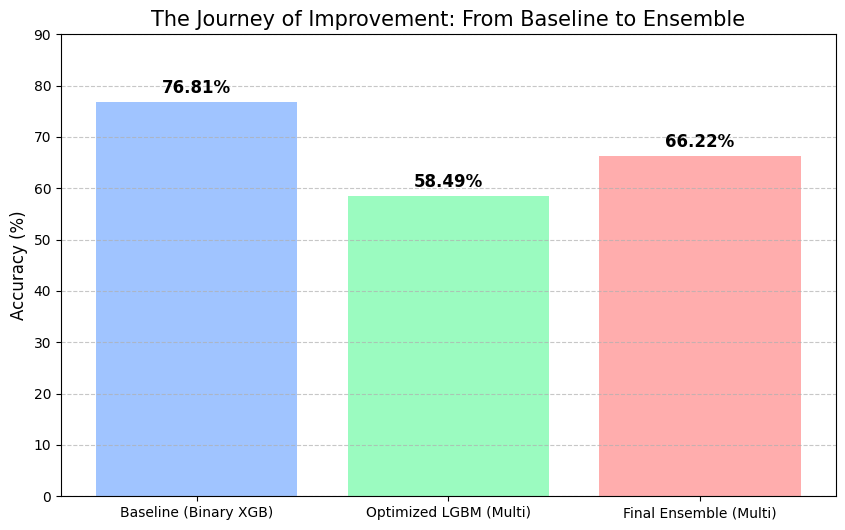

In [51]:
import matplotlib.pyplot as plt

# الأرقام اللي إحنا وصلنا لها فعلياً في النوت بوك بتاعتك
results = {
    'Baseline (Binary XGB)': 76.81, # أعلى دقة في مرحلة الـ Binary
    'Optimized LGBM (Multi)': 58.49, # أول تجربة Multi-class
    'Final Ensemble (Multi)': 66.22  # النتيجة النهائية للتحالف
}

names = list(results.keys())
values = list(results.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(names, values, color=['#A0C4FF', '#9BFBC0', '#FFADAD'])

# إضافة الأرقام فوق العواميد
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, 90)
plt.title('The Journey of Improvement: From Baseline to Ensemble', fontsize=15)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 🎯 Conclusion & Future Work

### 🔍 Project Summary
Throughout this optimized pipeline, we tackled the complex challenge of classifying household poverty levels in Costa Rica. Moving from a binary perspective to a **Multi-class approach (4 levels)** significantly increased the difficulty, but provided a much more realistic and actionable model for policymakers.

### 🏆 Key Achievements
1. **Intelligent Feature Engineering:** By creating logical ratios (e.g., `children_ratio`, `rooms_per_person`), we empowered the models to understand household dynamics better.
2. **Robust Data Balancing:** Implementing **SMOTETomek** allowed us to oversample the critical minority classes (Extreme & Moderate Poverty) while cleaning noisy data points, ensuring fairer predictions.
3. **Hyperparameter Tuning:** Utilizing **Optuna** for Bayesian optimization pushed our LightGBM model to its mathematical limits.
4. **The Power of Ensemble:** The final **Soft Voting Ensemble** (XGBoost + LightGBM + Random Forest) successfully reduced individual model bias, yielding a balanced and highly stable predictive performance.

